# Agent-based models and Simulation based inference

In [ ]:
# import os
# !git clone https://github.com/LostMa-ERC/ABM_SBI_workshop.git
# os.chdir('ABM_SBI_workshop')
# !pip install sbi

import bd_sbi
import birth_death_utils as bd
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm

from sbi.analysis import pairplot
from sbi.inference import NPE, simulate_for_sbi, NLE
from sbi.utils import BoxUniform

from torch import Tensor

# 1) Loading dataset

In [16]:
x_obs_stemmata = bd_sbi.load_stemmata("corpus_stemmata")
x_obs_2wits = bd_sbi.load_2_wits_texts('Old_French_witnesses.csv')

  0%|          | 0/107 [00:00<?, ?it/s]

Median number of witnesses: 2.0
f2/f1: 0.3177570093457944
(f1+f2)/f_>: 1.0444444444444445


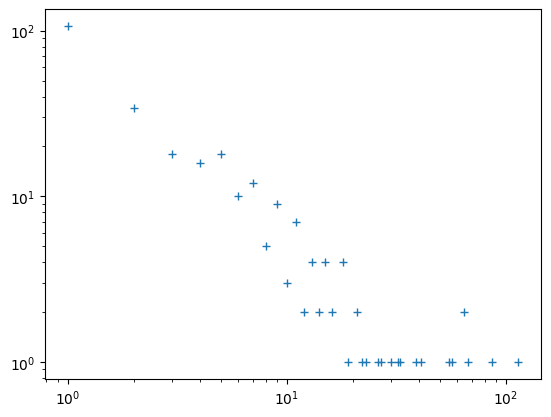

In [6]:
df = pd.read_csv('Old_French_witnesses.csv')
works = list(df['text H-ID'])
nb_wits = list(Counter(works).values())
c = Counter(nb_wits)
x = c.keys()
y = c.values()
plt.loglog(x,y,'+')
print(f'Median number of witnesses: {np.median(nb_wits)}')
print(f'f2/f1: {c[2]/c[1]}')
print(f'(f1+f2)/f_>: {(c[1]+c[2]) / sum([c[k] for k in c.keys() if k >2])}')


In [17]:
x_obs_empirical = x_obs_stemmata + x_obs_2wits[:18] + [[1, 0, -1,-1,-1,-1,-1,-1,-1] for n in range(57)]

# 2) Simulation based inference -- Training Neural Likelihood Estimator

## a) Constant-rates birth-death model

**Step 1:** define prior distribution on parameters (uniform distribution on an interval)

In [24]:
lambda_min_prior = 4.*10**(-3)
lambda_max_prior = 9.*10**(-3)

mu_min_prior = 1.*10**(-3)
mu_max_prior = 5*10**(-3)

N_samples_prior = 5000
N_samples_posterior = 1000

**Step 2:** Simulate training data, drawing parameters values from the prior

In [25]:
def simulator(theta):
    '''
    Wrapper function for the birth-death simulator
    '''
    l = theta[0]
    m = theta[1]
    return bd_sbi.generate_tree_crbd(l,m,1000,1000)

prior = BoxUniform(low=Tensor([lambda_min_prior, mu_min_prior]), high=Tensor([lambda_max_prior, mu_max_prior]))
theta0 = prior.sample((N_samples_prior,))

theta  = []
x = []

for t in tqdm(theta0):
    vec = bd_sbi.compute_summary_stats(simulator(t))
    if vec != None:
        theta.append(list(t))
        x.append(vec)

  0%|          | 0/5000 [00:00<?, ?it/s]

**Step 3:** Train Neural Likelihood Estimator on simulated trees

In [26]:
inference = NLE(prior=prior)
inference = inference.append_simulations(Tensor(theta), Tensor(x))
inference.train()

 Neural network successfully converged after 552 epochs.

NFlowsFlow(
  (net): Flow(
    (_transform): CompositeTransform(
      (_transforms): ModuleList(
        (0): PointwiseAffineTransform()
        (1): MaskedAffineAutoregressiveTransform(
          (autoregressive_net): MADE(
            (initial_layer): MaskedLinear(in_features=9, out_features=50, bias=True)
            (context_layer): Linear(in_features=2, out_features=50, bias=True)
            (blocks): ModuleList(
              (0-1): 2 x MaskedFeedforwardBlock(
                (linear): MaskedLinear(in_features=50, out_features=50, bias=True)
                (dropout): Dropout(p=0.0, inplace=False)
              )
            )
            (final_layer): MaskedLinear(in_features=50, out_features=18, bias=True)
          )
        )
        (2): RandomPermutation()
        (3): MaskedAffineAutoregressiveTransform(
          (autoregressive_net): MADE(
            (initial_layer): MaskedLinear(in_features=9, out_features=50, bias=True)
            (context_layer): Linear(in_featur

**Step 4:** Sample from posterior distribution

In [27]:
posterior = inference.build_posterior()
samples = posterior.sample((N_samples_posterior,), x= x_obs_empirical)

Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/6000 [00:00<?, ?it/s]

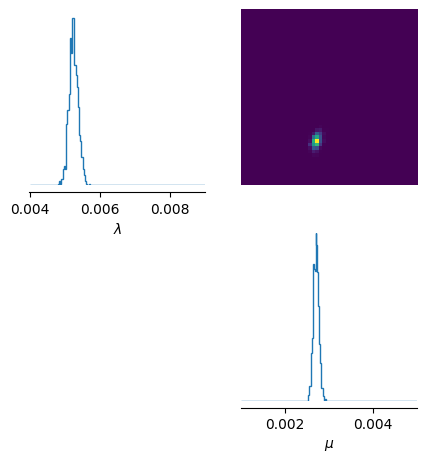

In [23]:
_ = pairplot(
    samples,
    limits=[[lambda_min_prior, lambda_max_prior], [mu_min_prior, mu_max_prior]],
    figsize=(5, 5),
    labels=[r"$\lambda$", r"$\mu$"]
)

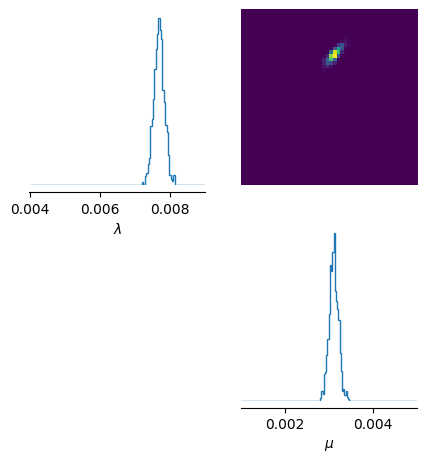

In [45]:
_ = pairplot(
    samples,
    limits=[[lambda_min_prior, lambda_max_prior], [mu_min_prior, mu_max_prior]],
    figsize=(5, 5),
    labels=[r"$\lambda$", r"$\mu$"]
)

## b) Birth-death model with continuous production decay

In [ ]:
lambda_min_prior = 4.*10**(-3)
lambda_max_prior = 9.*10**(-3)

mu_min_prior = 1.*10**(-3)
mu_max_prior = 5*10**(-3)

N_samples_prior = 1000
N_samples_posterior = 1000

In [ ]:
def simulator(theta):
    '''
    Wrapper function for the birth-death simulator
    '''
    l0 = theta[0]
    m = theta[1]
    return bd_sbi.generate_tree_bd_decay(l0,m,1000,1000)

prior = BoxUniform(low=Tensor([lambda_min_prior, mu_min_prior]), high=Tensor([lambda_max_prior, mu_max_prior]))
theta0 = prior.sample((N_samples_prior,))

theta  = []
x = []

for t in tqdm(theta0):
    vec = bd_sbi.compute_summary_stats(simulator(t))
    if vec != None:
        theta.append(list(t))
        x.append(vec)

In [ ]:
inference = NLE(prior=prior)
inference = inference.append_simulations(Tensor(theta), Tensor(x))
inference.train()

In [ ]:
posterior = inference.build_posterior()
samples = posterior.sample((N_samples_posterior,), x= x_obs_empirical)

In [ ]:
_ = pairplot(
    samples,
    limits=[[lambda_min_prior, lambda_max_prior], [mu_min_prior, mu_max_prior]],
    figsize=(5, 5),
    labels=[r"$\lambda$", r"$\mu$"]
)

## c) Birth-death model with mass extinction crisis

In [ ]:
lambda_min_prior = 4.*10**(-3)
lambda_max_prior = 9.*10**(-3)

mu_min_prior = 1.*10**(-3)
mu_max_prior = 5*10**(-3)

N_samples_prior = 1000
N_samples_posterior = 1000

In [ ]:
def simulator(theta):
    '''
    Wrapper function for the birth-death simulator
    '''
    l0 = theta[0]
    m = theta[1]
    return bd_sbi.generate_tree_bd_decim(l0,m,1000,1000, 500, 0.4)

prior = BoxUniform(low=Tensor([lambda_min_prior, mu_min_prior]), high=Tensor([lambda_max_prior, mu_max_prior]))
theta0 = prior.sample((N_samples_prior,))

theta  = []
x = []

for t in tqdm(theta0):
    vec = bd_sbi.compute_summary_stats(simulator(t))
    if vec != None:
        theta.append(list(t))
        x.append(vec)

In [ ]:
inference = NLE(prior=prior)
inference = inference.append_simulations(Tensor(theta), Tensor(x))
inference.train()